### 2 Week 7 [Feb 10 - Feb 16]: Collaborative Filtering Recommender System

1. Based on the frequency of the most rated items computed in Week 6, implement the TopPop recommender system, which always recommends
the same top-k items sorted decreasingly by the number of “high” ratings (e.g., ≥ 3) in the training split, train.tsv.

In [6]:
import pandas as pd

class TopPop:
    def __init__(self, k=10):
        self.k = k
        self.top_items = None

    def fit(self, file_path):
        # Read the training data (no header assumed)
        df = pd.read_csv(file_path, sep='\t')
        # Keep only the high ratings (e.g., >= 3)
        df_high = df[df['rating'] >= 3]
        # Compute the frequency of high ratings per item and sort in decreasing order
        counts = df_high['item_id'].value_counts()
        self.top_items = list(counts.index)

    def recommend(self, user_id):
        # Return the top-k items (this model is user-agnostic)
        return self.top_items[:self.k]
    
top_pop = TopPop(k=10)
top_pop.fit('Data/clean_train.tsv')

2. Choose at least one neighborhood-based model and one latent factor model that uses the observed user-item ratings in the training set to predict the unobserved ratings. Report your choice of models.

In [7]:
from surprise import Dataset, Reader, KNNWithMeans, SVD
import pandas as pd

# Load your training data from the file (in 'Data/clean_train.tsv')
df = pd.read_csv('Data/clean_train.tsv', sep='\t')
reader = Reader(rating_scale=(1, 5))

# Prepare the dataset using the surprise framework
data = Dataset.load_from_df(df[['user_id', 'item_id', 'rating']], reader)
trainset = data.build_full_trainset()

3. Use 5-fold cross-validation on the training set to tune the hyperparameters of the chosen models (similarity measure and number of neighbors for the neighborhood-based model; number of latent factors and number of epochs for the latent factor model).

In [8]:
from surprise.model_selection import GridSearchCV
import random
import numpy as np

# Set the random seed for reproducibility
random.seed(42)
np.random.seed(42)

# Define parameter grid for KNNWithMeans (neighborhood-based model)
param_grid_knn = {
    'k': [5, 10, 20, 30, 40, 50, 70, 100],
    'verbose': [False],
    'sim_options': {
        'name': ['cosine', 'msd'],
        'user_based': [True]  # We use user-based collaborative filtering
    },
    'random_state': [42]
}

# Define parameter grid for SVD (latent factor model)
param_grid_svd = {
    'n_factors': [3, 5, 10, 20, 50, 100],
    'n_epochs': [5, 10, 20, 50, 100],
    'random_state': [42]
}

# Perform 5-fold cross-validation for KNNWithMeans
grid_knn = GridSearchCV(KNNWithMeans, param_grid_knn, measures=['rmse', 'mae'], cv=5)
grid_knn.fit(data)

# Perform 5-fold cross-validation for SVD
grid_svd = GridSearchCV(SVD, param_grid_svd, measures=['rmse', 'mae'], cv=5)
grid_svd.fit(data)

4. Choose an evaluation measure that is suitable for this task and justify your motivation in using it. Report the optimal hyperparameters together with the scores of your chosen measure, averaged over the 5 folds.

In [9]:
# We choose RMSE (Root Mean Squared Error) as the evaluation measure

print("\nKNNWithMeans Best Hyperparameters (based on RMSE):")
print(grid_knn.best_params['rmse'])
print("Average RMSE for KNNWithMeans:", grid_knn.best_score['rmse'])

print("\nSVD Best Hyperparameters (based on RMSE):")
print(grid_svd.best_params['rmse'])
print("Average RMSE for SVD:", grid_svd.best_score['rmse'])


KNNWithMeans Best Hyperparameters (based on RMSE):
{'k': 70, 'verbose': False, 'sim_options': {'name': 'cosine', 'user_based': True}, 'random_state': 42}
Average RMSE for KNNWithMeans: 0.9100087207501553

SVD Best Hyperparameters (based on RMSE):
{'n_factors': 5, 'n_epochs': 20, 'random_state': 42}
Average RMSE for SVD: 0.8440025192355


5. Run the models with the optimal hyperparameters to the whole training set.

In [10]:
# Re-train the models on the full training set using the optimal hyperparameters from the grid searches

# For KNNWithMeans
knn_best = grid_knn.best_estimator['rmse']
knn_best.fit(trainset)

# For SVD
svd_best = grid_svd.best_estimator['rmse']
svd_best.fit(trainset)

print("KNNWithMeans model trained with optimal hyperparameters.")
print("SVD model trained with optimal hyperparameters.")

KNNWithMeans model trained with optimal hyperparameters.
SVD model trained with optimal hyperparameters.


6. Use the final models to rank the non-rated items for each user. This ranking will be used for the evaluation part next week.

In [11]:
from collections import defaultdict

# Build the anti-testset (all user-item pairs not in the training set)
anti_testset = trainset.build_anti_testset()

# Get predictions on the anti-testset using the KNNWithMeans model
predictions = knn_best.test(anti_testset)

# Group predictions by user
user_recs = defaultdict(list)
for pred in predictions:
    user_recs[pred.uid].append((pred.iid, pred.est))

# For each user, sort the recommendations in descending order of predicted rating
for user in user_recs:
    user_recs[user] = [iid for iid, _ in sorted(user_recs[user], key=lambda x: x[1], reverse=True)]

# Display sample recommendations for a few users
print("Sample recommendations using KNNWithMeans:")
for user, recs in list(user_recs.items())[:5]:
    print(f"User {user}: {recs[:10]}")

# Get predictions on the anti-testset using the SVD model
predictions = svd_best.test(anti_testset)

# Group predictions by user
user_recs = defaultdict(list)
for pred in predictions:
    user_recs[pred.uid].append((pred.iid, pred.est))

# For each user, sort the recommendations in descending order of predicted rating
for user in user_recs:
    user_recs[user] = [iid for iid, _ in sorted(user_recs[user], key=lambda x: x[1], reverse=True)]

# Display sample recommendations for a few users
print("Sample recommendations using SVD:")
for user, recs in list(user_recs.items())[:5]:
    print(f"User {user}: {recs[:10]}")


Sample recommendations using KNNWithMeans:
User AGTVZ7ZSDMTEDLMJGZRC7RFJNDWQ: ['B0C67HCGBR', 'B0BPJ4Q6FJ', 'B0B8M5FJB6', 'B00H35YIJE', 'B079TLFL33', 'B000T9L7W2', 'B007MY5BDI', 'B00H4PEMM6', 'B09YDBKT7M', 'B0002D0Q2W']
User AG44UYFDZHI6FRBQSLDWOGIEOY4A: ['B0C67HCGBR', 'B0B8M5FJB6', 'B000T9L7W2', 'B007MY5BDI', 'B09YDBKT7M', 'B079P9LDHN', 'B0BPKTYTPQ', 'B001W99HE8', 'B000J5UEGQ', 'B01DBS2U9G']
User AE7P3HIBI3UDLCJLUPUZQWYVPEWA: ['B005M0MUQK', 'B0BRS6V8G4', 'B078L11275', 'B09R6KV6QX', 'B07YK57N2M', 'B00RX5HQS4', 'B0BQ4HSKC9', 'B086QM1F75', 'B07R3S93K8', 'B09WF82F1V']
User AE5M7M2VYMM3WHJIBLCHHEU7UOXQ: ['B06XB3FQKB', 'B0BPJ4Q6FJ', 'B0B8M5FJB6', 'B079TLFL33', 'B007MY5BDI', 'B00H4PEMM6', 'B09YDBKT7M', 'B0BXT384GR', 'B079P9LDHN', 'B0BPKH4HB2']
User AESDNHQRRZEWTZF7A7TFFFTSNY5Q: ['B0BGQZNQ53', 'B07L5B64RG', 'B07Y94MSG9', 'B0CB98SMQR', 'B079NS31NK', 'B00CIHB8FY', 'B000SHQ1QC', 'B0BQ4HSKC9', 'B00IZA1GI2', 'B000U0DU34']
Sample recommendations using SVD:
User AGTVZ7ZSDMTEDLMJGZRC7RFJNDWQ: ['B0BPJ4

### 3 Week 8 [Feb 17 - Feb 23]: Evaluation of Recommender Systems

In this session, we will discuss how to evaluate a recommender system. Specifically, let us evaluate all your recommender models from Week 7 on the preprocessed test data split studied in Week 6. You need to:
- Measure the error of the system’s predicted likelihood of rating for the items (Root Mean Square Error, RMSE).
- Discuss the limitations of this metric.

In [12]:
from surprise import accuracy

# Load the preprocessed test data (assuming same structure as train data: user_id, item_id, rating)
test_df = pd.read_csv('Data/clean_test.tsv', sep='\t')

# Convert the test DataFrame to a list of (user, item, rating) tuples
testset = [tuple(x) for x in test_df[['user_id', 'item_id', 'rating']].values]

# Evaluate SVD model on the test set
svd_predictions = svd_best.test(testset)
print("SVD RMSE on test set:")
accuracy.rmse(svd_predictions, verbose=True)

# Evaluate KNNWithMeans model on the test set
knn_predictions = knn_best.test(testset)
print("KNNWithMeans RMSE on test set:")
accuracy.rmse(knn_predictions, verbose=True)

SVD RMSE on test set:
RMSE: 0.9795
KNNWithMeans RMSE on test set:
RMSE: 1.0619


1.0618532415444242

Now, we are interested not in whether the system properly predicts the rating of these items, but rather whether the system gives the best recommendations for each user. To evaluate this, generate the top-k (with k = 10) recommendation for each test user. Based on the top-k recommendation list generated for each user, and using the test data split5, compute:
- Hit rate, averaged across users.
- Precision@k, averaged across users
- Mean Average Precision (MAP@k)
- Mean Reciprocal Rank (MRR@k)
- Coverage

Discuss the advantages and disadvantages of these metrics.
Compare the two types of CF recommender systems and the TopPop system that we have defined so far. Which one works best? Why? What are the advantages and limitations of each approach?

In [13]:
# Prepare ground truth for each test user (using binary labels)
# Relevant (1) if rating >= 4; not relevant (0) otherwise.
ground_truth = defaultdict(set)
for _, row in test_df.iterrows():
    if row['rating'] >= 4:
        ground_truth[row['user_id']].add(row['item_id'])

# Function to generate top-k recommendations using a given model.
# For personalized models we use the anti-testset from the training set.
def get_top_k(model, trainset, k=10):
    # Build the anti-testset (all unseen items for every user in the trainset)
    anti_testset = trainset.build_anti_testset()
    predictions = model.test(anti_testset)
    
    recommendations = defaultdict(list)
    for pred in predictions:
        recommendations[pred.uid].append((pred.iid, pred.est))
    
    # For each user, sort predicted items in descending order and select top-k.
    for user in recommendations:
        recommendations[user] = [iid for iid, _ in sorted(recommendations[user], key=lambda x: x[1], reverse=True)[:k]]
    return recommendations

# For TopPop (non-personalized), the top-k recommendations are the same for every user.
def get_top_k_for_top_pop(top_pop, test_users, k=10):
    recs = {}
    top_items = top_pop.top_items[:k]
    for user in test_users:
        recs[user] = top_items
    return recs

# Generate recommendations for each model.
# Retrieve the list of test users from ground_truth.
test_users = list(ground_truth.keys())

svd_recs = get_top_k(svd_best, trainset, k=10)
knn_recs = get_top_k(knn_best, trainset, k=10)
top_pop_recs = get_top_k_for_top_pop(top_pop, test_users, k=10)

# Get the total catalog size (we use all items from the training split)
total_items = trainset.n_items

# Evaluation function for hit rate, precision@k, MAP@k, MRR@k and coverage.
def evaluate(recs, ground_truth, k=10, total_items=total_items):
    hit_rates = []
    precisions = []
    avg_precisions = []
    reciprocal_ranks = []
    rec_items = set()
    
    for user, true_items in ground_truth.items():
        recommended = recs.get(user, [])
        rec_items.update(recommended)
        # Hit rate: at least one relevant item recommended.
        hit = 1 if set(recommended) & true_items else 0
        hit_rates.append(hit)
        # Precision@k: fraction of recommended items that are relevant.
        precision = len(set(recommended) & true_items) / k
        precisions.append(precision)
        # Average Precision (AP@k)
        ap = 0
        hit_count = 0
        for i, item in enumerate(recommended):
            if item in true_items:
                hit_count += 1
                ap += hit_count / (i + 1)
        if len(true_items) > 0:
            ap /= len(true_items)
        avg_precisions.append(ap)
        # Reciprocal Rank (MRR@k): rank of the first relevant recommendation.
        rr = 0
        for i, item in enumerate(recommended):
            if item in true_items:
                rr = 1 / (i + 1)
                break
        reciprocal_ranks.append(rr)
    
    hit_rate = np.mean(hit_rates)
    precision_at_k = np.mean(precisions)
    map_at_k = np.mean(avg_precisions)
    mrr_at_k = np.mean(reciprocal_ranks)
    # Coverage: unique items recommended over catalog total.
    coverage = len(rec_items) / total_items
    
    return hit_rate, precision_at_k, map_at_k, mrr_at_k, coverage

# Evaluate each recommender.
svd_metrics = evaluate(svd_recs, ground_truth, k=10)
knn_metrics = evaluate(knn_recs, ground_truth, k=10)
top_pop_metrics = evaluate(top_pop_recs, ground_truth, k=10)

print("SVD:    Hit Rate, Precision@10, MAP@10, MRR@10, Coverage =", svd_metrics)
print("KNN:    Hit Rate, Precision@10, MAP@10, MRR@10, Coverage =", knn_metrics)
print("TopPop: Hit Rate, Precision@10, MAP@10, MRR@10, Coverage =", top_pop_metrics)

SVD:    Hit Rate, Precision@10, MAP@10, MRR@10, Coverage = (0.0825242718446602, 0.00825242718446602, 0.00610439651075204, 0.02219140083217753, 0.11787819253438114)
KNN:    Hit Rate, Precision@10, MAP@10, MRR@10, Coverage = (0.10922330097087378, 0.011650485436893206, 0.00841981197641613, 0.03142144398212359, 0.587426326129666)
TopPop: Hit Rate, Precision@10, MAP@10, MRR@10, Coverage = (0.25728155339805825, 0.032524271844660196, 0.03386359713699836, 0.11868354137771613, 0.019646365422396856)


#### Analysis on the effect of the long-tail

Sort the users by number of ratings in the train set and select the top 20% and last 20% of users.

In [14]:
# Compute the number of ratings per user from the trainset
user_rating_counts = {trainset.to_raw_uid(uid): len(ratings) for uid, ratings in trainset.ur.items()}

# Sort users by their number of ratings
sorted_users = sorted(user_rating_counts.items(), key=lambda x: x[1])
num_users = len(sorted_users)

# Determine the 20% count for top and bottom users
num_20_percent = int(num_users * 0.2)

# Select bottom 20% (users with fewest ratings) and top 20% (users with most ratings)
bottom_users = [user for user, count in sorted_users[:num_20_percent]]
top_users = [user for user, count in sorted_users[-num_20_percent:]]

print("Total number of users:", num_users)
print("Bottom 20% users and their review counts:")
for user in bottom_users:
    print(f"{user}: {user_rating_counts[user]}")
print("Top 20% users and their review counts:")
for user in top_users:
    print(f"{user}: {user_rating_counts[user]}")

Total number of users: 800
Bottom 20% users and their review counts:
AF2MGAQBAT3E4XQC7NNAQFYG4MIQ: 1
AGMYRILPTJDOK7WL5OYHYGRYVXMQ: 1
AEMZMINSQYQBEDD3TPDQZZFFWIQA: 1
AGDEYWGZKNGR36MRO7ZT3AB45AXA: 1
AHMUAUOHLITDKIKI4C3KVRWIBMAQ: 1
AFFOT7AORQAWKU6KKPDHR3FOA5AA: 1
AEXXX2MQRH3AHZMBZBP4RDNGRRWQ: 1
AFGJ42MV2H2CHEZNN3JPQ3RSYUHQ: 1
AESA6T5VF3ADXH5GYRX2RDMN6I6Q: 1
AEWWDVYR4YKLLOILS55VQISDPGYQ: 2
AHOUKQ3IRAEAMEHDB6U4AMB366NQ: 2
AGSP5XAQPQBUUXZHEZSC65FD7NOQ: 2
AH2RITMRQC3JL44WADB4GV23AFVQ: 2
AF63VW7YLF42A6STVGBLACD7RUWA: 2
AHMMZCKZMV7U5SPYVE6IG2YACR7Q: 2
AHMVWBJ4FNFOXJ6BXA5M7CEDHSNA: 2
AHRPODCFJ7UNWQKCLLBKN6BQIN7A: 2
AHWAYCEX3NCWJD32JTFVBFXKUHOQ: 2
AGHARSG3LRWDNOAM3HVDWKJJMS3Q: 2
AE2NWSTL7JJJWOCBKZCZF6KDQIZQ: 3
AGRGLPIRFOMTUIBIYJOUTTGZHABA: 3
AETS7HNSQIFRSMRCWQMHIWZ2IBOQ: 3
AGHJMMZCZKGM2XC7E32JDSAGRWHQ: 3
AHUIUCGSUO6B2KRQLQ2UWRYXTH5Q: 3
AF72XXUN4AGVL4K45BIXLKDIZRTQ: 3
AEYWZ24XFZCRP3PXNJB2TLXFX47A: 3
AEWQYNFYO55WCN2IVUVQET3OFS6A: 4
AE6ZIS54JBDY3UPZQGSXRJMPQ3OA: 4
AH44K3RPIQMVWG2G4EB5FPVIVUEQ: 4
AGY

Compute Hit rate on the test set for the 2 groups of users and discuss the difference (or similarity) between those scores.

In [15]:
# Restrict ground_truth to the two user groups (from cell 20)
gt_top = {user: items for user, items in ground_truth.items() if user in top_users}
gt_bottom = {user: items for user, items in ground_truth.items() if user in bottom_users}

# Compute the metrics for each group using the existing evaluate function.
# Here, we extract the hit rate (index 0 of the returned tuple).

svd_top_metrics = evaluate(svd_recs, gt_top, k=10, total_items=total_items)
svd_bottom_metrics = evaluate(svd_recs, gt_bottom, k=10, total_items=total_items)
print("SVD Hit Rate for Top 20% Users:", svd_top_metrics[0])
print("SVD Hit Rate for Bottom 20% Users:", svd_bottom_metrics[0])

# Compute metrics for KNNWithMeans on top and bottom users.
knn_top_metrics = evaluate(knn_recs, gt_top, k=10, total_items=total_items)
knn_bottom_metrics = evaluate(knn_recs, gt_bottom, k=10, total_items=total_items)
print("KNN Hit Rate for Top 20% Users:", knn_top_metrics[0])
print("KNN Hit Rate for Bottom 20% Users:", knn_bottom_metrics[0])

# Compute metrics for TopPop on top and bottom users.
top_pop_top_metrics = evaluate(top_pop_recs, gt_top, k=10, total_items=total_items)
top_pop_bottom_metrics = evaluate(top_pop_recs, gt_bottom, k=10, total_items=total_items)
print("TopPop Hit Rate for Top 20% Users:", top_pop_top_metrics[0])
print("TopPop Hit Rate for Bottom 20% Users:", top_pop_bottom_metrics[0])

SVD Hit Rate for Top 20% Users: 0.09836065573770492
SVD Hit Rate for Bottom 20% Users: 0.11949685534591195
KNN Hit Rate for Top 20% Users: 0.18032786885245902
KNN Hit Rate for Bottom 20% Users: 0.14465408805031446
TopPop Hit Rate for Top 20% Users: 0.16393442622950818
TopPop Hit Rate for Bottom 20% Users: 0.3710691823899371


Sort the items by number of ratings in the train set and select the top 20% and last 20% of items.

In [16]:
# Calculate the number of ratings for each item in the trainset
item_rating_counts = {}
for inner_iid, user_ratings in trainset.ir.items():
    raw_iid = trainset.to_raw_iid(inner_iid)
    item_rating_counts[raw_iid] = len(user_ratings)

# Sort items by the count of ratings (ascending order)
sorted_items = sorted(item_rating_counts.items(), key=lambda x: x[1])
num_items = len(sorted_items)
num_20_percent = int(num_items * 0.2)

# Select bottom 20% (items with fewest ratings)
bottom_20_items = [item for item, count in sorted_items[:num_20_percent]]

# Select top 20% (items with most ratings)
top_20_items = [item for item, count in sorted_items[-num_20_percent:]]

print("Total number of items:", num_items)
print("Bottom 20% items:", bottom_20_items)
print("Top 20% items:", top_20_items)

Total number of items: 509
Bottom 20% items: ['B07KRZ1HH8', 'B0BNCDVD4M', 'B0B2LMZ9RT', 'B0C5CTX5LZ', 'B07DVX841V', 'B075MCRFYZ', 'B08Y6PVK2L', 'B073RTT48C', 'B08PBNXZYP', 'B0B63DPVDK', 'B00GGMWA5O', 'B07YMGPV7P', 'B0BGQZNQ53', 'B09JYJYK1N', 'B00ABLI0IC', 'B01LEZVYZO', 'B09Y5NZ8PN', 'B07BFZ2KSJ', 'B0C6HXYY3R', 'B07M6B3RDW', 'B07MDT5WJX', 'B01FM8IN3U', 'B01HUCYOXE', 'B078JQV1DN', 'B07HGRFG5J', 'B07BRK2M2Q', 'B09Y1X5BSC', 'B0BFR5LN7M', 'B0BT2Q355P', 'B086PLHS9L', 'B00X7DDGBW', 'B09B45DLQG', 'B0002MSQVQ', 'B09NLV5LBK', 'B0BJF97MDV', 'B0776RBZF1', 'B00CIHB8FY', 'B07RLVH6H4', 'B08T9CCXZB', 'B07ND5PQTP', 'B00HU25WSQ', 'B0192JRA2A', 'B07VPLFNYM', 'B01M5CXH65', 'B01LYJMH9P', 'B0BJ8WDC13', 'B09QZJ57YW', 'B01LKYTQOK', 'B0777KT21W', 'B0C1Y5KJPX', 'B0035LCFRW', 'B000EEL50Q', 'B09G5KDVWW', 'B07Y94MSG9', 'B000PR3JEM', 'B0002D0MI0', 'B0158GWWJ2', 'B0085545YO', 'B0BJ3BBTXH', 'B09JMYM88H', 'B00724YM7E', 'B092LF6RLS', 'B00LYFFW9O', 'B01LL8PRIY', 'B01LZBHHC2', 'B076ZSHQ47', 'B0B81FBRNV', 'B0756P1DV8', 'B

Compute Coverage on the test set for the 2 groups of items and discuss the difference (or similarity) between those scores.

In [17]:
# Function to compute coverage for a given recommender's recommendations.
def compute_coverage(recs, group_top, group_bottom, model_name):
    rec_top = set()
    rec_bottom = set()
    for user in test_users:
        rec_list = recs.get(user, [])
        rec_top.update(set(rec_list).intersection(group_top))
        rec_bottom.update(set(rec_list).intersection(group_bottom))
    coverage_top = len(rec_top) / len(group_top) if group_top else 0
    coverage_bottom = len(rec_bottom) / len(group_bottom) if group_bottom else 0
    print(f"{model_name} Coverage for Top 20% Items: {coverage_top:.4f}")
    print(f"{model_name} Coverage for Bottom 20% Items: {coverage_bottom:.4f}\n")

# Compute and print coverage for each model.
compute_coverage(svd_recs, top_20_items, bottom_20_items, "SVD")
compute_coverage(knn_recs, top_20_items, bottom_20_items, "KNNWithMeans")
compute_coverage(top_pop_recs, top_20_items, bottom_20_items, "TopPop")

SVD Coverage for Top 20% Items: 0.1881
SVD Coverage for Bottom 20% Items: 0.0198

KNNWithMeans Coverage for Top 20% Items: 0.4752
KNNWithMeans Coverage for Bottom 20% Items: 0.6238

TopPop Coverage for Top 20% Items: 0.0990
TopPop Coverage for Bottom 20% Items: 0.0000



#### Error analysis for the neighborhood-based CF

Select two users from the training set, one with high RR and one with low RR. These are your reference users. Retrieve the 10 nearest neighbours of each reference user. Print their rating history and analyse their predictions. How much overlap is there between the rating history of the reference users and their neighbours?

For those users or items that your model performs poorly on (RR ≤ 0.05), discuss the potential reasons behind.

In [18]:
# Compute per-user Reciprocal Rank (RR) for the KNN model using the recommendations in knn_recs
user_rr = {}
for user, true_items in ground_truth.items():
    rec = knn_recs.get(user, [])
    rr = 0
    for i, item in enumerate(rec):
        if item in true_items:
            rr = 1.0 / (i + 1)
            break
    user_rr[user] = rr

# Sort users by RR (highest first)
sorted_rr = sorted(user_rr.items(), key=lambda x: x[1], reverse=True)
print("Top 5 users with highest RR:", sorted_rr[:5])
print("Top 5 users with lowest RR:", sorted_rr[-5:])

# Select one reference user with highest RR and one with lowest RR
high_rr_user = sorted_rr[0][0]
low_rr_user = sorted_rr[-1][0]
print(f"\nSelected high RR user: {high_rr_user} (RR = {user_rr[high_rr_user]})")
print(f"Selected low RR user: {low_rr_user} (RR = {user_rr[low_rr_user]})")

# Function to get the k nearest neighbors (using knn_best of the neighborhood-based model)
def get_neighbors(user_id, k=10):
    inner_uid = trainset.to_inner_uid(user_id)
    neighbor_inner = knn_best.get_neighbors(inner_uid, k=k)
    return [trainset.to_raw_uid(nid) for nid in neighbor_inner]

high_rr_neighbors = get_neighbors(high_rr_user, k=10)
low_rr_neighbors = get_neighbors(low_rr_user, k=10)
print(f"\nHigh RR user neighbors: {high_rr_neighbors}")
print(f"Low RR user neighbors: {low_rr_neighbors}")

# Function to obtain the rating history of a user from the training set
def get_rating_history(user_id):
    inner_uid = trainset.to_inner_uid(user_id)
    # trainset.ur is a dict: key is inner_uid, value is list of (inner_iid, rating)
    history = trainset.ur[inner_uid]
    return [(trainset.to_raw_iid(iid), rating) for iid, rating in history]

# Print rating history for each reference user and their neighbors
print("\nHigh RR user rating history:")
high_rr_history = get_rating_history(high_rr_user)
print(high_rr_history)

print("\nHigh RR user neighbors' rating histories:")
for neighbor in high_rr_neighbors:
    print(f"Neighbor {neighbor}: {get_rating_history(neighbor)}")

print("\nLow RR user rating history:")
low_rr_history = get_rating_history(low_rr_user)
print(low_rr_history)

print("\nLow RR user neighbors' rating histories:")
for neighbor in low_rr_neighbors:
    print(f"Neighbor {neighbor}: {get_rating_history(neighbor)}")

# Overlap analysis: for each neighbor compare the set of rated items with the reference user.
def compute_overlap(ref_history, neighbor_history):
    ref_items = set(item for item, _ in ref_history)
    neighbor_items = set(item for item, _ in neighbor_history)
    common = ref_items.intersection(neighbor_items)
    return len(common), len(ref_items), len(neighbor_items), common

print("\nOverlap analysis for high RR user:")
high_total_overlap = 0
for neighbor in high_rr_neighbors:
    overlap, ref_count, neigh_count, common_items = compute_overlap(high_rr_history, get_rating_history(neighbor))
    print(f"Neighbor {neighbor}: {overlap} common items (Reference rated {ref_count}, Neighbor rated {neigh_count})")
    high_total_overlap += overlap
high_avg_overlap = high_total_overlap / len(high_rr_neighbors)
print(f"\nAverage overlap for high RR user with neighbors: {high_avg_overlap:.2f}")

print("\nOverlap analysis for low RR user:")
low_total_overlap = 0
for neighbor in low_rr_neighbors:
    overlap, ref_count, neigh_count, common_items = compute_overlap(low_rr_history, get_rating_history(neighbor))
    print(f"Neighbor {neighbor}: {overlap} common items (Reference rated {ref_count}, Neighbor rated {neigh_count})")
    low_total_overlap += overlap
low_avg_overlap = low_total_overlap / len(low_rr_neighbors)
print(f"\nAverage overlap for low RR user with neighbors: {low_avg_overlap:.2f}")

Top 5 users with highest RR: [('AHGDGGMCSMMALHTX6WGLJFFUVJXA', 1.0), ('AHN535MBJTI4BGLTUORFR3TLABLA', 1.0), ('AFJ52QWR6Y5WPXK3MEZJJBHMUY7A', 1.0), ('AFMOXNCYTYVRTZKJGVX4X7NHOU7Q', 1.0), ('AH2KNTQFU4DWMQIMTDLFSMRQHRYA', 0.5)]
Top 5 users with lowest RR: [('AG5ZVXXHEXDYUUODSEQC4XXV7DPA', 0), ('AFKZTCN4BNEKHAJQARBTQ4RZVETQ', 0), ('AH5MZVAOBU2PWPJ2G663BY5S2R5A', 0), ('AEIRBLA7WN4R3DFFWOUBDY6UYWEA', 0), ('AENTQR2OEQO7IPIVUMHMV545FPJA', 0)]

Selected high RR user: AHGDGGMCSMMALHTX6WGLJFFUVJXA (RR = 1.0)
Selected low RR user: AENTQR2OEQO7IPIVUMHMV545FPJA (RR = 0)

High RR user neighbors: ['AE5M7M2VYMM3WHJIBLCHHEU7UOXQ', 'AESDNHQRRZEWTZF7A7TFFFTSNY5Q', 'AHEJYPLN7DMCYRQ2KCWQ5YIY6JDA', 'AG4VWLJ2X7PIBYDXYYUNFY5ONDRQ', 'AEBXDQP3DYUQMQUTAUIMYMOMSRZQ', 'AEDKV2KYMJZD43MAADUEKE7Z3PPA', 'AHJPWPHCWZ5MX2UY6CNGJUNBWP3A', 'AEOOBBNDQVLYBDVJLE4GJUCWX42A', 'AGXCV25HDW4JXI5QQSJTIZUHPRHQ', 'AENYK6CKXCHJDY2YV3WIQZMJ3HNQ']
Low RR user neighbors: ['AE7P3HIBI3UDLCJLUPUZQWYVPEWA', 'AESDNHQRRZEWTZF7A7TFFFTSNY5Q', 'AG

### Week 9 [Feb 24 - Mar 2]: Text Representation

In this part, we will work with the text content from the dataset and will apply NLP techniques to represent items and users in a vector space.

1. Note: for this part, you are free to use all or a subset of the metadata file, e.g., only using items that are in the train/test splits or using the first n characters of the text content. Please justify your choice.

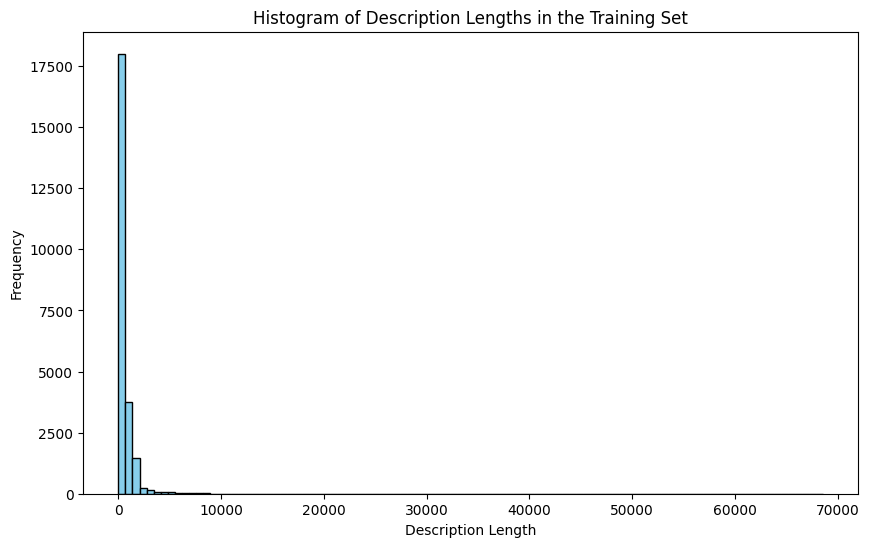

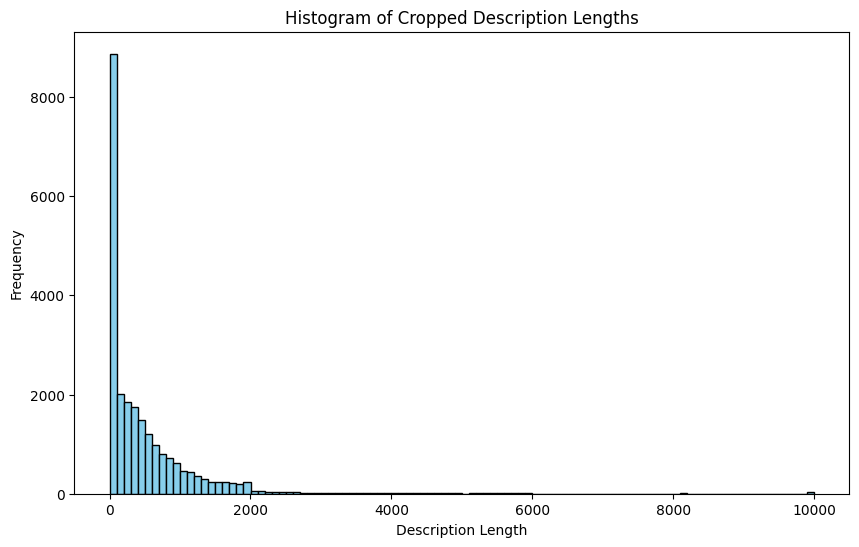

Percentage of reviews shorter than 2000 chars: 96.50%
Percentage of reviews shorter than 1000 chars: 84.48%
Percentage of reviews shorter than 500 chars: 66.51%


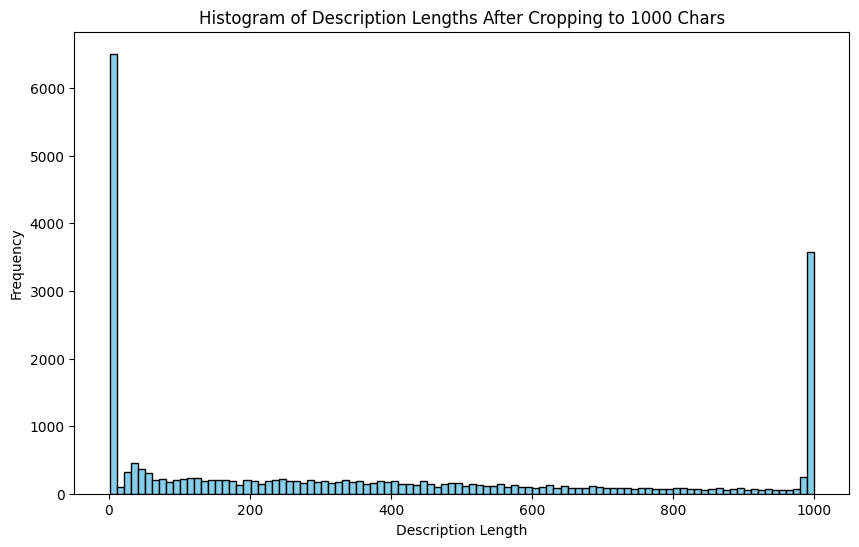

In [19]:
import matplotlib.pyplot as plt

# Load the metadata containing item descriptions (if not already loaded)
df_meta = pd.read_csv('Data/metadata.tsv', sep='\t')

# Compute the length of each description (convert to string to avoid NaN issues)
df_meta['desc_len'] = df_meta['description'].astype(str).apply(len)

# Plot a histogram of the description lengths
plt.figure(figsize=(10, 6))
plt.hist(df_meta['desc_len'], bins=100, color='skyblue', edgecolor='black')
plt.xlabel('Description Length')
plt.ylabel('Frequency')
plt.title('Histogram of Description Lengths in the Training Set')
plt.show()

# Crop descriptions longer than 10000 characters
df_meta['description'] = df_meta['description'].astype(str).apply(lambda x: x[:10000] if len(x) > 10000 else x)
# Recompute description lengths after cropping
df_meta['desc_len'] = df_meta['description'].apply(len)

# Plot histogram of the new description lengths
plt.figure(figsize=(10, 6))
plt.hist(df_meta['desc_len'], bins=100, color='skyblue', edgecolor='black')
plt.xlabel('Description Length')
plt.ylabel('Frequency')
plt.title('Histogram of Cropped Description Lengths')
plt.show()

total_reviews = len(df_meta)
reviews_lt_2000 = (df_meta['desc_len'] < 2000).sum()
reviews_lt_1000 = (df_meta['desc_len'] < 1000).sum()
reviews_lt_500 = (df_meta['desc_len'] < 500).sum()

perc_lt_2000 = reviews_lt_2000 / total_reviews * 100
perc_lt_1000 = reviews_lt_1000 / total_reviews * 100
perc_lt_500 = reviews_lt_500 / total_reviews * 100

print(f"Percentage of reviews shorter than 2000 chars: {perc_lt_2000:.2f}%")
print(f"Percentage of reviews shorter than 1000 chars: {perc_lt_1000:.2f}%")
print(f"Percentage of reviews shorter than 500 chars: {perc_lt_500:.2f}%")

# Crop descriptions to keep only the first 1000 characters
def crop_text(text):
    # If the string is less than or equal to 1000 characters, return it as is.
    if len(text) <= 1000:
        return text
    # Find the last space before the 1000th character.
    cut_index = text.rfind(' ', 0, 1000)
    # If no space is found, break at 1000 characters.
    if cut_index == -1:
        cut_index = 1000
    return text[:cut_index]

df_meta['description'] = df_meta['description'].astype(str).apply(crop_text)
# Recompute description lengths after cropping
df_meta['desc_len'] = df_meta['description'].apply(len)

# Plot histogram of the new description lengths after cropping
plt.figure(figsize=(10, 6))
plt.hist(df_meta['desc_len'], bins=100, color='skyblue', edgecolor='black')
plt.xlabel('Description Length')
plt.ylabel('Frequency')
plt.title('Histogram of Description Lengths After Cropping to 1000 Chars')
plt.show()

2. Select the column description from the metadata file and apply appropriate preprocessing to clean up the data, for example: tokenization, transformation to lowercase, stopword removal6, or stemming. Motivate your preprocessing choices and report the vocabulary size before and after preprocessing. There are many libraries you can use, including but not limited to, NLTK, spaCy or CoreNLP (requires Java).

In [20]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
import string

nltk.download('punkt')
nltk.download('stopwords')

# Get the raw descriptions from the metadata DataFrame
descriptions = df_meta['description'].dropna().astype(str).tolist()

# Define stopwords and stemmer
stop_words = set(stopwords.words('english'))
stemmer = SnowballStemmer(language='english')

# Preprocess function: tokenize, lower, remove punctuation, numbers and stopwords, and stem
def preprocess_text(text):
    # Tokenize and lowercase
    tokens = [word.lower() for word in word_tokenize(text)]
    # Remove punctuation tokens, stopwords, and tokens containing any digits
    tokens = [token for token in tokens if token not in string.punctuation and token not in stop_words and not any(ch.isdigit() for ch in token)]
    # Stem tokens
    tokens = [stemmer.stem(token) for token in tokens]
    return tokens

# Build a vocabulary from the raw descriptions (lowercased tokens)
raw_vocab = set()
for text in descriptions:
    tokens = word_tokenize(text.lower())
    raw_tokens = [token for token in tokens if token not in string.punctuation]
    raw_vocab.update(raw_tokens)

# Build a vocabulary from the preprocessed descriptions
processed_vocab = set()
for text in descriptions:
    tokens = preprocess_text(text)
    processed_vocab.update(tokens)

print("Vocabulary size before preprocessing:", len(raw_vocab))
print("Vocabulary size after preprocessing:", len(processed_vocab))

# Create a new column 'preprocessed_description' by applying the preprocessing function 
df_meta['preprocessed_description'] = df_meta['description'].apply(lambda x: ' '.join(preprocess_text(x)))

# Print a sample original and its preprocessed description
sample_index = 0  # you can change the index to view a different sample
print("Original Description:")
print(df_meta['description'].iloc[sample_index])
print("\nPreprocessed Description:")
print(df_meta['preprocessed_description'].iloc[sample_index])

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\david\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\david\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Vocabulary size before preprocessing: 51296
Vocabulary size after preprocessing: 27243
Original Description:
BEHRINGER EUROPOWER EPQ900. Professional 900-Watt Light Weight Stereo Power Amplifier with ATR (Accelerated Transient Response) Technology. 2 x 390 Watts into 4 Ohms; 2 x 245 Watts into 8 Ohms. 2 x 390 Watts into 4 Ohms; 2 x 245 Watts into 8 Ohms. ATR (Accelerated Transient Response) technology for ultimate punch and clarity. ATR (Accelerated Transient Response) technology for ultimate punch and clarity. Ultra-light, ultra-low noise and ultra-efficient switch-mode power supply for noise-free audio, superior transient response and low power consumption. Ultra-light, ultra-low noise and ultra-efficient switch-mode power supply for noise-free audio, superior transient response and low power consumption. Independent limiters for each channel offer maximum output level with reliable overload protection. Independent limiters for each channel offer maximum output level with reliable ov

3. Represent each item in the TF-IDF vector space. You can use your preferred library for text representation, for example, scikit-learn or gensim.

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Use preprocessed text and split on spaces without additional preprocessing.
tfidf_vectorizer = TfidfVectorizer(tokenizer=lambda x: x.split(), lowercase=False)
tfidf_matrix = tfidf_vectorizer.fit_transform(df_meta['preprocessed_description'])

print("TF-IDF matrix shape:", tfidf_matrix.shape)

c:\Users\david\anaconda3\envs\WRS\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


TF-IDF matrix shape: (23984, 27243)


4. Represent each item using pretrained word embeddings (e.g., GloVe, word2vec).

In [22]:
import os
import gensim
import gensim.downloader as api
import numpy as np

w2v_path = 'Data/GoogleNews-vectors-negative300.bin'

try:
    word2vec = gensim.models.KeyedVectors.load_word2vec_format(w2v_path, binary=True)
except FileNotFoundError:
    print("Downloading word2vec-google-news-300...")
    word2vec = api.load("word2vec-google-news-300")

def get_avg_word2vec(tokens, model):
    vectors = [model[token] for token in tokens if token in model]
    return np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size)

df_meta['w2v_vector'] = df_meta['preprocessed_description'].apply(lambda txt: get_avg_word2vec(txt.split(), word2vec))

print("Sample word2vec representation (vector shape):", df_meta['w2v_vector'].iloc[0].shape)


Sample word2vec representation (vector shape): (300,)


5. Explore the similarity between items within the vector spaces by computing their cosine similarity. Compare results obtained with TF-IDF and the word embeddings. Discuss what you find. Note that you can select a subset of items to better highlight the differences between the two text representations.

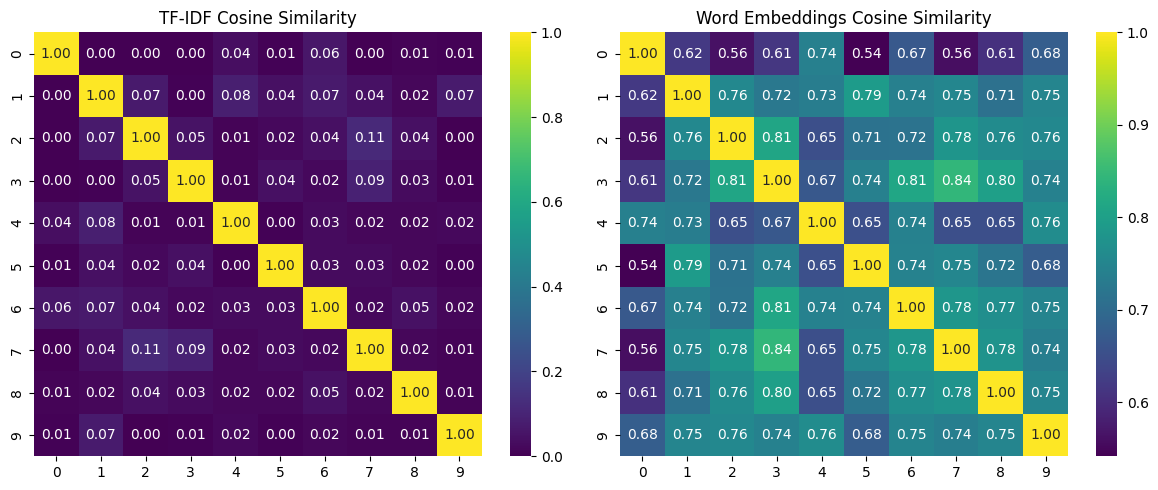

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Select a subset of items (e.g., the first 10 items with more than 900 characters)
subset = df_meta[df_meta['desc_len'] > 900].iloc[:10]

# TF-IDF similarity
subset_tfidf = tfidf_matrix[subset.index, :]
tfidf_sim = cosine_similarity(subset_tfidf)

# Word Embedding similarity: stack the w2v_vector representations into a matrix
subset_w2v = np.stack(subset['w2v_vector'].values)
w2v_sim = cosine_similarity(subset_w2v)

# Plot similarity matrices side by side
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(tfidf_sim, annot=True, fmt=".2f", cmap="viridis")
plt.title("TF-IDF Cosine Similarity")

plt.subplot(1, 2, 2)
sns.heatmap(w2v_sim, annot=True, fmt=".2f", cmap="viridis")
plt.title("Word Embeddings Cosine Similarity")

plt.tight_layout()
plt.show()


6. [Optional] Represent each item rated by the users using the word vectors from the last layer of BERT. Here, you can directly use the vectors from the pretrained version of BERT available in huggingface. To load the model, install the Transformers library and PyTorch.

BERT representations computed for each item.


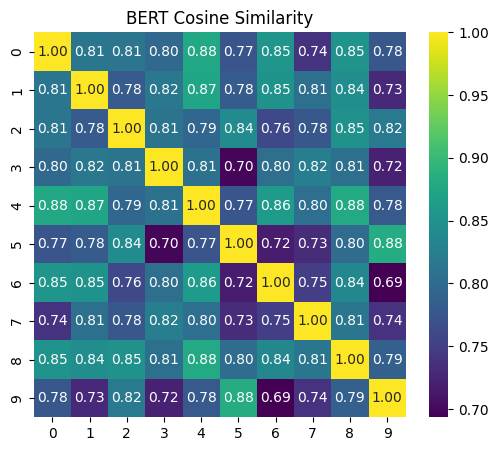

In [24]:
import torch
from transformers import BertModel, BertTokenizer

!pip install transformers torch --quiet


# Load model and tokenizer
model_name = "bert-base-uncased"
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertModel.from_pretrained(model_name)
model.eval()  # set model to evaluation mode

# Optionally, move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Function to get BERT representation (using the [CLS] token) for a given text.
def get_bert_vector(text):
    # Handle potential issues with NaN or empty strings
    if not text or text.lower() == "nan":
        return torch.zeros(model.config.hidden_size)
    # Tokenize text with truncation to max_length 512 tokens.
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512, padding="max_length")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
    # Use [CLS] token (first token) from the last hidden state as the representation.
    cls_vector = outputs.last_hidden_state[:, 0, :].squeeze().cpu()
    return cls_vector

# Compute BERT representations for items in the 'description' column of the subset.
bert_vectors = subset['description'].apply(lambda x: get_bert_vector(str(x)))
print("BERT representations computed for each item.")

# Convert BERT tensors to numpy arrays and stack them
bert_matrix = np.stack(bert_vectors.apply(lambda vec: vec.numpy()).tolist())
bert_sim = cosine_similarity(bert_matrix)

# Plot the cosine similarity matrix for BERT representations
plt.figure(figsize=(6, 5))
sns.heatmap(bert_sim, annot=True, fmt=".2f", cmap="viridis")
plt.title("BERT Cosine Similarity")
plt.show()


### Week 10 [Mar 3 - Mar 9]: Content-Based Recommender System

In this week, we will continue using the train and test splits defined in Week 6.
- Note: similar to the task in Week 9, for this part, you are free to only use a subset of the metadata file, e.g., only using items that are in the train/test splits or using the first n characters/words of the text content.
You are also welcome to use additional metadata (e.g., by crawling the internet). Please report and justify your choice.

In [25]:
print("Number of rows:", df_meta.shape[0])
print("Number of fields:", df_meta.shape[1])
max_length = df_meta['description'].astype(str).apply(len).max()
print("Max length of strings in 'description':", max_length)
print("\nColumns and their data types:")
print(df_meta.dtypes)

Number of rows: 23984
Number of fields: 6
Max length of strings in 'description': 1000

Columns and their data types:
item_id                     object
title                       object
description                 object
desc_len                     int64
preprocessed_description    object
w2v_vector                  object
dtype: object


- Transform the description column of each item into a TF-IDF representation or other numerical value, e.g., token-count based, that can represent the summaries. Select at least one other factor that can be used as an item feature, for example title. Apply the appropriate preprocessing on the features. These choices should also be reported and justified.

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

# Preprocess the title column using the same preprocessing function already defined for descriptions.
# (Assuming there is a 'title' column in df_meta)
df_meta['preprocessed_title'] = df_meta['title'].astype(str).apply(lambda x: ' '.join(preprocess_text(x)))

# Build a TF-IDF representation for the preprocessed titles.
title_tfidf_vectorizer = TfidfVectorizer(tokenizer=lambda x: x.split(), lowercase=False)
tfidf_title_matrix = title_tfidf_vectorizer.fit_transform(df_meta['preprocessed_title'])

# Combine the description TF-IDF matrix (tfidf_matrix, already computed) with the title TF-IDF matrix.
combined_features = hstack([tfidf_matrix, tfidf_title_matrix])

# For each item, store its combined feature vector as a new column.
# Each row is a sparse vector; we extract it as a CSR matrix slice.
df_meta['combined_features'] = [combined_features.getrow(i) for i in range(combined_features.shape[0])]

print("TF-IDF description vector length:", tfidf_matrix.shape[1])
print("TF-IDF title vector length:", tfidf_title_matrix.shape[1])
print("Combined feature vector length:", combined_features.shape[1])

c:\Users\david\anaconda3\envs\WRS\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


TF-IDF description vector length: 27243
TF-IDF title vector length: 14307
Combined feature vector length: 41550


- After you represent each item in a vector space, represent each user in the same vector space. This can be done by using a simple average of the items the user rated. Note that you can also try to implement better ways to build the user representation.

In [27]:
# Build a mapping from item_id (from metadata) to its combined feature vector (a sparse row)
item_profiles = dict(zip(df_meta['item_id'], df_meta['combined_features']))

# Determine the number of features from the first item's vector
num_features = df_meta['combined_features'].iloc[0].toarray().shape[1]

# Create user profiles using only reviews in the training set with ratings >= 1.
user_profiles = {}
for inner_uid, ratings in trainset.ur.items():
    raw_uid = trainset.to_raw_uid(inner_uid)
    # Collect the dense vectors of items rated >= 1 by the user.
    vectors = []
    for inner_iid, rating in ratings:
        if rating >= 1:
            raw_iid = trainset.to_raw_iid(inner_iid)
            if raw_iid in item_profiles:
                # Convert the sparse item vector to a dense array.
                item_vector = item_profiles[raw_iid].toarray().flatten()
                vectors.append(item_vector)
    # Compute the average of the selected vectors, or initialize with a zero vector if none.
    if vectors:
        user_profile = np.mean(vectors, axis=0)
    else:
        user_profile = np.zeros(num_features)
    user_profiles[raw_uid] = user_profile

print("Created user profiles for {} users using only items with ratings >= 1.".format(len(user_profiles)))

Created user profiles for 800 users using only items with ratings >= 1.


- Calculate the user-item rating prediction for an item by using a similarity/distance metric between the user and the item representations. A metric such as cosine similarity or Euclidean distance can be used. Motivate your choice.

In [28]:
import random
from sklearn.metrics import mean_squared_error

def predict_rating(user_id, item_id, min_rating=1, max_rating=5):
    # Retrieve the user profile vector and item feature vector.
    user_vector = user_profiles.get(user_id)
    if user_vector is None:
        print("Unknown user.")
        return None
    if item_id not in item_profiles:
        print("Unknown item.")
        return None

    # Convert the sparse item vector to a dense representation.
    item_vector = item_profiles[item_id].toarray().flatten()
    
    # Do NOT mean-center the item vector, since our user profiles are built from raw item vectors.
    # Reshape vectors to 2D arrays for cosine_similarity.
    user_vector_2d = user_vector.reshape(1, -1)
    item_vector_2d = item_vector.reshape(1, -1)
    
    # Compute cosine similarity between the user and item vectors.
    similarity = cosine_similarity(user_vector_2d, item_vector_2d)[0][0]
    
    # If your cosine similarities are in [0, 1] (common with non-negative vectors),
    # you may want to map directly as follows:
    # predicted_rating = similarity * (max_rating - min_rating) + min_rating
    #
    # Otherwise, if similarities can span [-1, 1], you can use:
    predicted_rating = (similarity + 1) * (max_rating - min_rating) / 2 + min_rating
    return predicted_rating

# Sample 100 random (user_id, item_id, rating) tuples from the test set.
sample_df = test_df.sample(n=100, random_state=42)

true_ratings = []
predicted_ratings_model = []    # Using predict_rating (content-based)
predicted_ratings_random = []   # Random predictor (uniformly random 1 to 5)
predicted_ratings_constant = [] # Constant predictor (always predict 3)

for _, row in sample_df.iterrows():
    user_id = row['user_id']
    item_id = row['item_id']
    true_rating = row['rating']
    
    # Content-based predictor from our model.
    pred = predict_rating(user_id, item_id)
    if pred is not None:
        true_ratings.append(true_rating)
        predicted_ratings_model.append(pred)
    else:
        print(f"Prediction not available for user {user_id} and item {item_id}")
    
    # Random predictor: generate a random float rating between 1 and 5.
    random_rating = random.uniform(1, 5)
    predicted_ratings_random.append(random_rating)
    
    # Constant predictor: always predict 3.
    predicted_ratings_constant.append(3)

# Compute RMSE for each predictor.
mse_model = mean_squared_error(true_ratings, predicted_ratings_model)
rmse_model = mse_model ** 0.5

mse_random = mean_squared_error(true_ratings, predicted_ratings_random)
rmse_random = mse_random ** 0.5

mse_constant = mean_squared_error(true_ratings, predicted_ratings_constant)
rmse_constant = mse_constant ** 0.5

print("RMSE for content-based predictor:", rmse_model)
print("RMSE for random predictor (ratings between 1-5):", rmse_random)
print("RMSE for constant predictor (always predict 3):", rmse_constant)

RMSE for content-based predictor: 1.6108212058352325
RMSE for random predictor (ratings between 1-5): 2.1563856220450646
RMSE for constant predictor (always predict 3): 1.7378147196982767


- Report Precision@10, MAP@10, MRR@10, hit rate and coverage using ratings ≥ 4 in the test set. Compare the results with the models from previous weeks.

In [29]:
from numpy.linalg import norm
import numpy as np
from tqdm import tqdm

# Precompute each item's raw vector and its norm (without subtracting the global mean).
item_vectors = {}
item_norms = {}
for item in item_profiles:
    vec = item_profiles[item].toarray().flatten()  # use raw vector
    item_vectors[item] = vec
    item_norms[item] = norm(vec)

# Use the unique users from sample_df instead of the first 5 users.
sample_users = test_df['user_id'].drop_duplicates().sample(n=10, random_state=42).tolist()

recs_sample = {}
all_items = set(item_profiles.keys())

# Process users from sample_df.
for user in tqdm(sample_users, desc="Processing sample_df users"):
    try:
        inner_uid = trainset.to_inner_uid(user)
        rated_items = {trainset.to_raw_iid(inner_iid) for inner_iid, _ in trainset.ur[inner_uid]}
    except Exception as e:
        rated_items = set()  # Assume no rated items if user not in training set.
    
    unobserved_items = list(all_items - rated_items)
    predictions = []
    user_vec = user_profiles[user]
    user_norm = norm(user_vec)
    
    for item in unobserved_items:
        vec = item_vectors[item]
        item_n = item_norms[item]
        if user_norm == 0 or item_n == 0:
            sim = 0
        else:
            sim = np.dot(user_vec, vec) / (user_norm * item_n)
        predictions.append((item, sim))
    
    predictions.sort(key=lambda x: x[1], reverse=True)
    top_10 = [item for item, sim in predictions[:10]]
    recs_sample[user] = top_10

# Filter ground_truth to only include users in sample_df.
filtered_ground_truth = {user: ground_truth[user] for user in sample_users if user in ground_truth}

# Evaluate the recommendations using the provided evaluate function.
results = evaluate(recs_sample, filtered_ground_truth, k=10, total_items=len(item_profiles))
print("Evaluation metrics for sample_df users (Hit Rate, Precision@10, MAP@10, MRR@10, Coverage):", results)


Processing sample_df users: 100%|██████████| 10/10 [00:34<00:00,  3.46s/it]

Evaluation metrics for sample_df users (Hit Rate, Precision@10, MAP@10, MRR@10, Coverage): (0.0, 0.0, 0.0, 0.0, 0.0039609739826551036)


### 6 Week 11 [Mar 10 - Mar 16] Hybrid Recommender System

Create three hybrid recommender systems by combining a collaborative filtering model with a content-based model using the following three strategies:
- Parallel combination strategy that re-ranks the items by combining the individual rankings from the two models with some aggregation function such as the sum, average, minimum or maximum

In [30]:
def create_hybrid_parallel(cf_recs, cb_recs, users, k=10, aggregation='sum'):
    """
    Create hybrid recommendations by combining collaborative filtering and content-based rankings.
    
    Parameters:
    cf_recs (dict): Dictionary mapping users to their collaborative filtering recommendations
    cb_recs (dict): Dictionary mapping users to their content-based recommendations
    users (list): List of users to generate recommendations for
    k (int): Number of recommendations to generate
    aggregation (str): Aggregation function ('sum', 'avg', 'min', 'max')
    
    Returns:
    dict: Dictionary mapping users to their hybrid recommendations
    """
    hybrid_recs = {}
    
    for user in users:
        # Get recommendations from both models
        cf_items = cf_recs.get(user, [])
        cb_items = cb_recs.get(user, [])
        
        # Skip if both recommendation lists are empty
        if not cf_items and not cb_items:
            continue
        
        # Create a dictionary to store combined scores
        item_scores = {}
        
        # Assign scores based on ranking in collaborative filtering recommendations
        for i, item in enumerate(cf_items):
            # Higher score for higher ranked items (inverse of position)
            item_scores[item] = k - i if i < k else 0
        
        # Combine with scores from content-based recommendations
        for i, item in enumerate(cb_items):
            score = k - i if i < k else 0
            if item in item_scores:
                if aggregation == 'sum':
                    item_scores[item] += score
                elif aggregation == 'avg':
                    item_scores[item] = (item_scores[item] + score) / 2
                elif aggregation == 'min':
                    item_scores[item] = min(item_scores[item], score)
                elif aggregation == 'max':
                    item_scores[item] = max(item_scores[item], score)
            else:
                item_scores[item] = score
        
        # Sort items by combined score in descending order
        sorted_items = sorted(item_scores.items(), key=lambda x: x[1], reverse=True)
        
        # Select top-k items
        hybrid_recs[user] = [item for item, _ in sorted_items[:k]]
    
    return hybrid_recs

# Test different aggregation methods for the hybrid recommender
aggregation_methods = ['sum']

for method in aggregation_methods:
    # Create hybrid recommendations
    hybrid_recs = create_hybrid_parallel(knn_recs, recs_sample, sample_users, aggregation=method)
    
    # Evaluate the hybrid recommendations
    parallel_results = evaluate(hybrid_recs, filtered_ground_truth, k=10, total_items=len(item_profiles))
    print(f"Hybrid Recommender ({method.capitalize()} Aggregation):", parallel_results)

# Compare with individual recommenders
print("\nComparison with individual recommenders:")
print("Content-Based:", results)  # Results from previous cell
print("KNN Collaborative Filtering:", knn_metrics)  # From previous evaluations


Hybrid Recommender (Sum Aggregation): (0.0, 0.0, 0.0, 0.0, 0.00333555703802535)

Comparison with individual recommenders:
Content-Based: (0.0, 0.0, 0.0, 0.0, 0.0039609739826551036)
KNN Collaborative Filtering: (0.10922330097087378, 0.011650485436893206, 0.00841981197641613, 0.03142144398212359, 0.587426326129666)


- Switching strategy that uses the recommendations from the collaborative filtering model for some users and the recommendations from the content-based model for other users chosen by a predefined condition.

In [31]:
def create_hybrid_switching(cf_recs, cb_recs, user_rating_counts, users, rating_threshold=None):
    """
    Create hybrid recommendations using a switching strategy based on user activity.
    
    Parameters:
    cf_recs (dict): Dictionary mapping users to their collaborative filtering recommendations
    cb_recs (dict): Dictionary mapping users to their content-based recommendations
    user_rating_counts (dict): Dictionary mapping users to their number of ratings
    users (list): List of users to generate recommendations for
    rating_threshold (int): Threshold for switching between models (if None, use median)
    
    Returns:
    dict: Dictionary mapping users to their hybrid recommendations
    tuple: Statistics about the switching (count of CF users, count of CB users)
    """
    hybrid_recs = {}
    
    # If no threshold provided, use the median number of ratings
    if rating_threshold is None:
        ratings = [user_rating_counts.get(user, 0) for user in users]
        rating_threshold = np.median(ratings)
    
    cf_user_count = 0
    cb_user_count = 0
    
    for user in users:
        # Determine which model to use based on user activity
        rating_count = user_rating_counts.get(user, 0)
        
        if rating_count >= rating_threshold:
            # Active users get collaborative filtering recommendations
            if user in cf_recs:
                hybrid_recs[user] = cf_recs[user]
                cf_user_count += 1
        else:
            # Less active users get content-based recommendations
            if user in cb_recs:
                hybrid_recs[user] = cb_recs[user]
                cb_user_count += 1
    
    return hybrid_recs, (cf_user_count, cb_user_count)

# Try different thresholds for switching
thresholds = [5]  # None will use median

for threshold in thresholds:
    # Create hybrid recommendations using switching strategy
    hybrid_recs, stats = create_hybrid_switching(
        knn_recs, recs_sample, user_rating_counts, sample_users, rating_threshold=threshold
    )
    
    # Evaluate the hybrid recommendations
    switching_results = evaluate(hybrid_recs, filtered_ground_truth, k=10, total_items=len(item_profiles))
    
    threshold_desc = f"median ({stats[0]+stats[1]//2})" if threshold is None else threshold
    print(f"Hybrid Switching Strategy (threshold={threshold_desc}):", switching_results)
    print(f"  Users with CF recommendations: {stats[0]}, Users with CB recommendations: {stats[1]}")

# Compare with individual recommenders
print("\nComparison with individual recommenders:")
print("Content-Based:", results)
print("KNN Collaborative Filtering:", knn_metrics)

Hybrid Switching Strategy (threshold=5): (0.1, 0.01, 0.003333333333333333, 0.016666666666666666, 0.0026267511674449634)
  Users with CF recommendations: 10, Users with CB recommendations: 0

Comparison with individual recommenders:
Content-Based: (0.0, 0.0, 0.0, 0.0, 0.0039609739826551036)
KNN Collaborative Filtering: (0.10922330097087378, 0.011650485436893206, 0.00841981197641613, 0.03142144398212359, 0.587426326129666)


- Pipelining (sequential) strategy where a level of one model is used as input to the other model.

In [32]:
#########################
# Pipeline: Content-Based → KNNWithMeans CF using sample_users with Progress Bar
#########################

def build_cb_rating_df(users, items, predict_func, min_rating=1, max_rating=5):
    """
    Build a synthetic user–item rating DataFrame by calling the content-based
    predict_rating function for each (user, item) pair.
    """
    rows = []
    # Use a progress bar for users
    for user_id in tqdm(users, desc="Building CB rating matrix"):
        for item_id in items:
            rating = predict_func(user_id, item_id, min_rating=min_rating, max_rating=max_rating)
            if rating is not None:
                rows.append((user_id, item_id, rating))
    return pd.DataFrame(rows, columns=['user_id', 'item_id', 'rating'])

# 1) Build a synthetic rating DataFrame from content-based predictions for sample_users only
all_items = list(item_profiles.keys())
df_cb = build_cb_rating_df(sample_users, all_items, predict_rating)

# 2) Load into Surprise and train a KNNWithMeans model on the synthetic ratings for sample_users
reader = Reader(rating_scale=(1, 5))
data_cb = Dataset.load_from_df(df_cb[['user_id', 'item_id', 'rating']], reader)
trainset_cb = data_cb.build_full_trainset()

knn_pipeline = KNNWithMeans(
    k=20, 
    sim_options={'name': 'cosine', 'user_based': True},
    verbose=False
)
knn_pipeline.fit(trainset_cb)

# 3) Build the anti_testset from the new trainset (which now only contains sample_users)
anti_testset = trainset_cb.build_anti_testset()

# Generate predictions on the anti_testset
predictions_cb = knn_pipeline.test(anti_testset)

# Convert raw predictions into top-10 lists for each user
cb_recs = {}
for uid, iid, _, est, _ in predictions_cb:
    cb_recs.setdefault(uid, []).append((iid, est))
for uid in cb_recs:
    cb_recs[uid].sort(key=lambda x: x[1], reverse=True)
    cb_recs[uid] = [iid for (iid, _) in cb_recs[uid][:10]]

# 4) Filter the ground truth to only include sample_users
filtered_ground_truth_sample = {u: ground_truth[u] for u in sample_users if u in ground_truth}

# 5) Evaluate with your existing function
pipeline_results = evaluate(cb_recs, filtered_ground_truth_sample, k=10, total_items=len(item_profiles))
print("Pipeline (Content→KNNWithMeans) results for sample_users:")
print("Hit Rate, Precision@10, MAP@10, MRR@10, Coverage =", pipeline_results)


Building CB rating matrix: 100%|██████████| 10/10 [05:23<00:00, 32.36s/it]


Pipeline (Content→KNNWithMeans) results for sample_users:
Hit Rate, Precision@10, MAP@10, MRR@10, Coverage = (0.0, 0.0, 0.0, 0.0, 0.0)


Use each hybrid model to rank the non-rated items for each user.

Regardless of the chosen option you need to Report Precision@10, MAP@10, MRR@10, the hit rate and coverage using ratings ≥ 4 in the test set. Compare the results with the models from previous weeks.

Recommender System Performance Comparison:


,Recommender,Hit Rate,Precision@10,MAP@10,MRR@10,Coverage
3,TopPop Baseline,0.257282,0.032524,0.033864,0.118684,0.019646
1,KNN Collaborative,0.109223,0.011650,0.008420,0.031421,0.587426
5,Switching Hybrid,0.100000,0.010000,0.003333,0.016667,0.002627
2,SVD Collaborative,0.082524,0.008252,0.006104,0.022191,0.117878
0,Content-Based,0.000000,0.000000,0.000000,0.000000,0.003961
4,Parallel Hybrid,0.000000,0.000000,0.000000,0.000000,0.003336
6,Pipeline Hybrid,0.000000,0.000000,0.000000,0.000000,0.000000


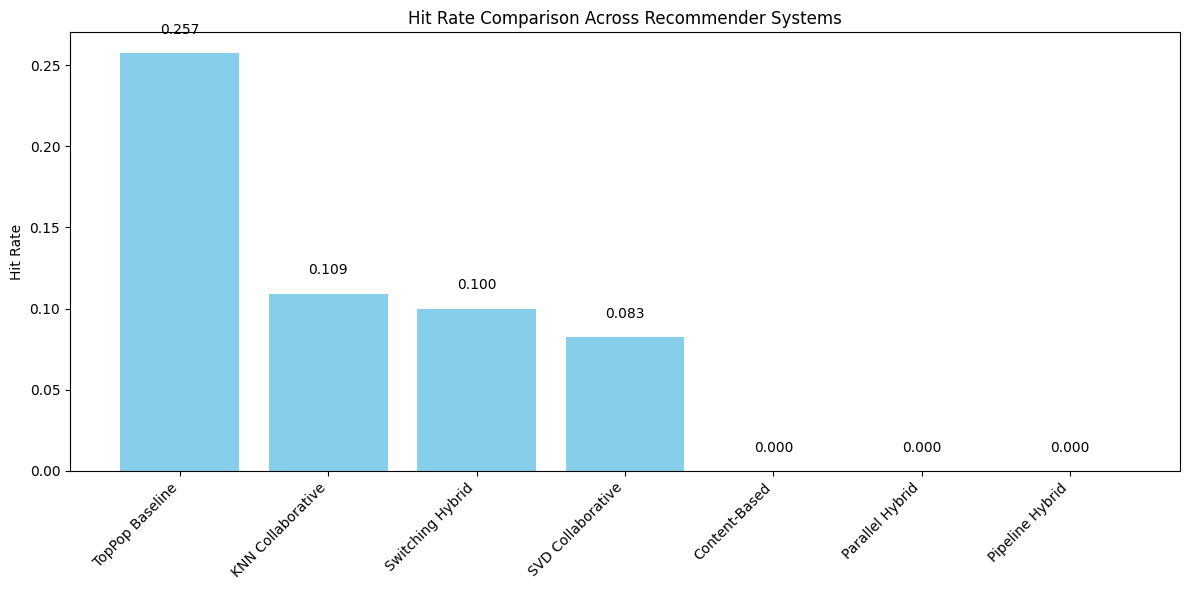

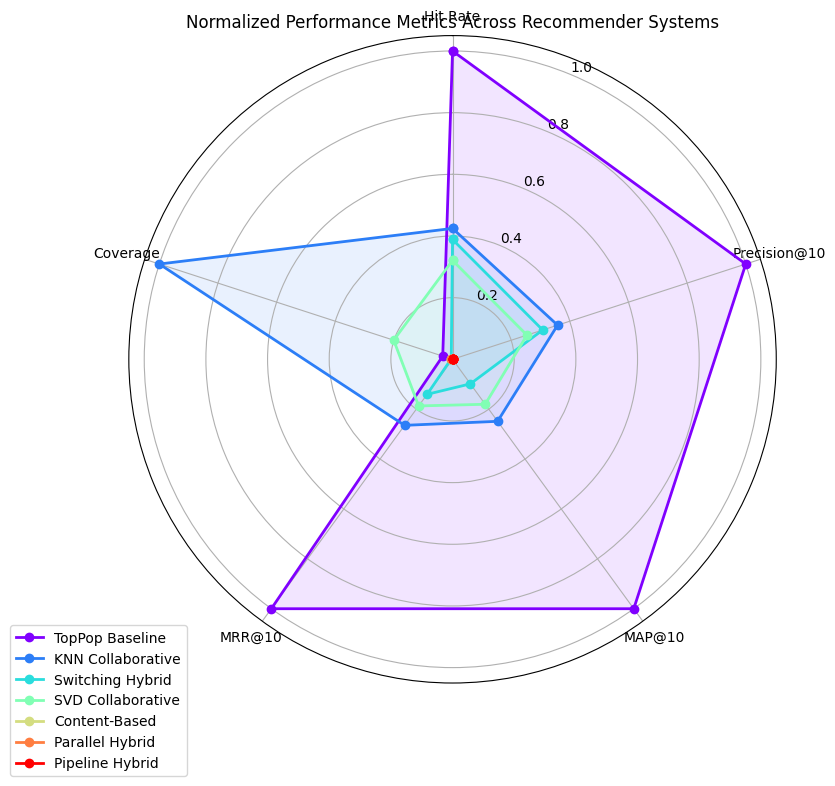

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm

# Collect metrics from all recommender types
systems = {
    "Content-Based": results,
    "KNN Collaborative": knn_metrics,
    "SVD Collaborative": svd_metrics,
    "TopPop Baseline": top_pop_metrics
}

# Add best hybrid recommenders
# For Parallel hybrid
systems["Parallel Hybrid"] = parallel_results

# For Switching hybrid
systems["Switching Hybrid"] = switching_results

# For Pipeline hybrid, use the specific result with multiplier=2 instead of the whole dictionary
systems["Pipeline Hybrid"] = pipeline_results

# Create a DataFrame to display the comparison
metrics_df = pd.DataFrame({
    "Recommender": list(systems.keys()),
    "Hit Rate": [systems[rec][0] for rec in systems],
    "Precision@10": [systems[rec][1] for rec in systems],
    "MAP@10": [systems[rec][2] for rec in systems],
    "MRR@10": [systems[rec][3] for rec in systems],
    "Coverage": [systems[rec][4] for rec in systems]
})

# Sort by Hit Rate descending
metrics_df = metrics_df.sort_values("Hit Rate", ascending=False)

# Display the table
print("Recommender System Performance Comparison:")
display(metrics_df)

# Create bar chart for visual comparison of hit rate
plt.figure(figsize=(12, 6))
bars = plt.bar(metrics_df["Recommender"], metrics_df["Hit Rate"], color="skyblue")
plt.ylabel("Hit Rate")
plt.title("Hit Rate Comparison Across Recommender Systems")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom')

plt.show()

# Create a radar chart to compare all metrics
metrics = ["Hit Rate", "Precision@10", "MAP@10", "MRR@10", "Coverage"]
# Normalize metrics for radar chart
normalized_df = metrics_df.copy()
for metric in metrics:
    max_val = normalized_df[metric].max()
    if max_val > 0:
        normalized_df[metric] = normalized_df[metric] / max_val

# Radar chart
colors = cm.rainbow(np.linspace(0, 1, len(systems)))

plt.figure(figsize=(10, 8))
angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]  # Close the loop

ax = plt.subplot(111, polar=True)
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

plt.xticks(angles[:-1], metrics)

for i, system in enumerate(normalized_df["Recommender"]):
    values = normalized_df.loc[normalized_df["Recommender"] == system, metrics].values.flatten().tolist()
    values += values[:1]  # Close the loop
    ax.plot(angles, values, 'o-', linewidth=2, label=system, color=colors[i])
    ax.fill(angles, values, alpha=0.1, color=colors[i])

plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
plt.title("Normalized Performance Metrics Across Recommender Systems")
plt.tight_layout()
plt.show()
